In [1]:
from PIL import Image
import numpy as np

blank = Image.open("train_data/empty_piano_score.png")
notes = np.array(Image.open("train_data/all_piano_notes_duration.png").convert('L')).T
example = np.array(Image.open('example.png').convert('L')).T

In [2]:
import matplotlib.pyplot as plt
def show(img):
    plt.imshow(img.T, cmap='gray')

def clean(img):
    img = img[25:]
    row_indices = [13, 20, 27, 34, 41]
    img[:, row_indices] = 255

In [3]:
first_truncate = 25
example = example[first_truncate:, :]

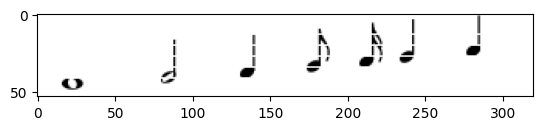

In [4]:
row_indices = [13, 20, 27, 34, 41]
example[:, row_indices] = 255
show(example)

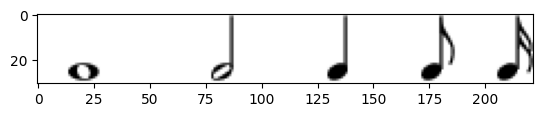

In [5]:
show(notes)

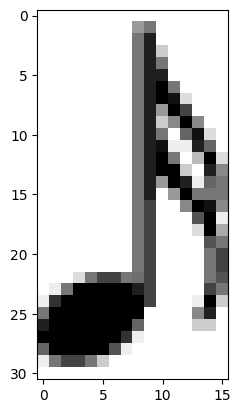

In [22]:
all_notes = []
duration = 0
note_started = False
start_idx = 0
end_idx = 0

for i, col in enumerate(notes):
    if not note_started and not np.all(col == 255):
        note_started=True
        start_idx = i
    elif note_started and np.all(col == 255):
        note_started=False
        end_idx = i

        all_notes.append(notes[start_idx:end_idx, :])
all_notes.append(notes[start_idx:, :])

show(all_notes[4])

In [40]:
all_notes = np.array([np.pad(x, pad_width=((0, 16 - x.shape[0]), (0, 0))) for x in all_notes])
np.argmin(np.mean(np.mean(np.abs(all_notes - all_notes[1]), axis=1), axis=1))

np.int64(1)

In [8]:
notes_in = []
duration = 0
note_started = False
start_idx = 0
end_idx = 0
arr = []

for i, col in enumerate(example):
    if not note_started and not np.all(col == 255):
        note_started=True
        start_idx = i
    elif note_started and np.all(col == 255):
        note_started=False
        end_idx = i

        note = example[start_idx:end_idx, :]
        for i, row in enumerate(note.T[::-1]):
            if not np.all(row == 255):
                arr.append(i)
                break

arr

[4, 8, 12, 15, 19, 21, 26]

In [43]:
types = ['1/1', '1/2', '1/4', '1/8', '1/16']
row_values = np.array([4, 8, 12, 15, 19, 21, 26])
rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
def identify_note(note):
    row = ''
    for i, row in enumerate(note.T[::-1]):
            if not np.all(row == 255):
                row = rows[np.where(row_values == i)[0][0]]
                break

    print(note.shape)
    pad_note = np.pad(note, pad_width=((0, 16 - note.shape[0]), (0, 0)))
    idx = np.argmin(np.mean(np.mean(np.abs(all_notes - pad_note), axis=1), axis=1))
    return (row + '-' + types[idx], 2.0**-idx)

def get_notes(example):
    

    outs = []
    duration = 0
    note_started = False
    start_idx = 0
    end_idx = 0

    for i, col in enumerate(example):
        if not note_started and not np.all(col == 255):
            note_started=True
            start_idx = i
        elif note_started and np.all(col == 255):
            note_started=False
            end_idx = i

            note = example[start_idx:end_idx, :]
            out, note_duration = identify_note(note)
            outs.append(out)
            duration+=note_duration

    return outs, duration
            
get_notes(example)

(14, 53)


ValueError: operands could not be broadcast together with shapes (5,16,31) (16,53) 